# Cross-Sectional Momentum — Nifty Large-Cap Universe
### Backtested systematic equity strategy with out-of-sample validation and factor analysis

**Hypothesis:** Stocks with the highest returns over the past 12 months (excluding the most
recent month) tend to outperform the following month. Buying the top decile monthly beats
the Nifty on a risk-adjusted basis after costs.

**Key design choices:**
- Walk-forward, no look-ahead bias
- 0.20% one-way transaction cost scaled by actual turnover
- In-sample (2010–2017) and out-of-sample (2018–2025) split for validation
- Robustness sweep across four lookback windows
- Sector exposure and market beta analysis

> **Survivorship bias present** — universe uses today's constituent list.
> Results overstate live performance. Estimated inflation: 2–5% CAGR.
> Educational project only. Not investment advice.
> Data: Yahoo Finance (yfinance). Not institutional grade.


## 0. Setup


In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy --quiet



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and settings


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

START       = '2010-01-01'
END         = '2025-01-01'
OOS_START   = '2018-01-01'   # out-of-sample period starts here
LOOKBACK    = 12
SKIP        = 1
TOP_PCT     = 0.10
COST        = 0.0020
BENCHMARK   = '^NSEI'
SAVE_DIR    = '.'


## 2. Stock universe

Representative large-cap NSE stocks from the Nifty 200 index family.
Sector classifications are hard-coded for the factor analysis in Section 9.

**Survivorship bias note:** this is today's survivor list.
Companies delisted between 2010–2025 are absent, inflating returns.


In [3]:
tickers = ["RELIANCE", "TCS", "HDFCBANK", "ICICIBANK", "INFY", "HINDUNILVR", "ITC", "SBIN", "BHARTIARTL", "KOTAKBANK", "LT", "AXISBANK", "BAJFINANCE", "ASIANPAINT", "MARUTI", "HCLTECH", "SUNPHARMA", "TITAN", "ULTRACEMCO", "WIPRO", "NESTLEIND", "ONGC", "NTPC", "POWERGRID", "TATAMOTORS", "TATASTEEL", "JSWSTEEL", "ADANIENT", "ADANIPORTS", "COALINDIA", "BAJAJFINSV", "BAJAJ-AUTO", "HEROMOTOCO", "EICHERMOT", "M&M", "DRREDDY", "CIPLA", "DIVISLAB", "APOLLOHOSP", "GRASIM", "BRITANNIA", "DABUR", "GODREJCP", "MARICO", "PIDILITIND", "BERGEPAINT", "HAVELLS", "DMART", "SBILIFE", "HDFCLIFE", "ICICIPRULI", "ICICIGI", "SHREECEM", "AMBUJACEM", "ACC", "VEDL", "HINDALCO", "JINDALSTEL", "SAIL", "NMDC", "TATAPOWER", "GAIL", "IOC", "BPCL", "INDUSINDBK", "BANKBARODA", "PNB", "CANBK", "IDFCFIRSTB", "FEDERALBNK", "AUBANK", "CHOLAFIN", "MUTHOOTFIN", "LICHSGFIN", "SIEMENS", "ABB", "BOSCHLTD", "BEL", "HAL", "BHEL", "LTIM", "MPHASIS", "PERSISTENT", "COFORGE", "TATAELXSI", "NAUKRI", "TRENT", "PAGEIND", "COLPAL", "TORNTPHARM", "LUPIN", "AUROPHARMA", "BIOCON", "ALKEM", "ZYDUSLIFE", "GLENMARK", "INDIGO", "DLF", "GODREJPROP", "OBEROIRLTY", "TVSMOTOR", "ASHOKLEY", "BALKRISIND", "MOTHERSON", "BHARATFORG", "CUMMINSIND", "TATACONSUM", "VOLTAS", "PIIND", "SRF", "UPL", "DEEPAKNTR", "TATACOMM", "PETRONET", "IGL", "TORNTPOWER", "NHPC", "IRCTC", "CONCOR", "RECLTD", "PFC", "POLYCAB"]
tickers = [t + '.NS' for t in tickers]

sector_map = {"TCS.NS": "IT", "INFY.NS": "IT", "HCLTECH.NS": "IT", "WIPRO.NS": "IT", "LTIM.NS": "IT", "MPHASIS.NS": "IT", "PERSISTENT.NS": "IT", "COFORGE.NS": "IT", "TATAELXSI.NS": "IT", "TATACOMM.NS": "IT", "NAUKRI.NS": "IT", "HDFCBANK.NS": "Financials", "ICICIBANK.NS": "Financials", "KOTAKBANK.NS": "Financials", "AXISBANK.NS": "Financials", "SBIN.NS": "Financials", "BAJFINANCE.NS": "Financials", "BAJAJFINSV.NS": "Financials", "INDUSINDBK.NS": "Financials", "BANKBARODA.NS": "Financials", "PNB.NS": "Financials", "CANBK.NS": "Financials", "IDFCFIRSTB.NS": "Financials", "FEDERALBNK.NS": "Financials", "AUBANK.NS": "Financials", "CHOLAFIN.NS": "Financials", "MUTHOOTFIN.NS": "Financials", "LICHSGFIN.NS": "Financials", "SBILIFE.NS": "Financials", "HDFCLIFE.NS": "Financials", "ICICIPRULI.NS": "Financials", "ICICIGI.NS": "Financials", "RECLTD.NS": "Financials", "PFC.NS": "Financials", "HINDUNILVR.NS": "Consumer", "ITC.NS": "Consumer", "NESTLEIND.NS": "Consumer", "BRITANNIA.NS": "Consumer", "DABUR.NS": "Consumer", "GODREJCP.NS": "Consumer", "MARICO.NS": "Consumer", "COLPAL.NS": "Consumer", "TATACONSUM.NS": "Consumer", "PAGEIND.NS": "Consumer", "TRENT.NS": "Consumer", "DMART.NS": "Consumer", "TITAN.NS": "Consumer", "ASIANPAINT.NS": "Consumer", "BERGEPAINT.NS": "Consumer", "LT.NS": "Industrials", "SIEMENS.NS": "Industrials", "ABB.NS": "Industrials", "BOSCHLTD.NS": "Industrials", "BEL.NS": "Industrials", "HAL.NS": "Industrials", "BHEL.NS": "Industrials", "CUMMINSIND.NS": "Industrials", "BHARATFORG.NS": "Industrials", "POLYCAB.NS": "Industrials", "HAVELLS.NS": "Industrials", "CONCOR.NS": "Industrials", "VOLTAS.NS": "Industrials", "INDIGO.NS": "Industrials", "IRCTC.NS": "Industrials", "ADANIENT.NS": "Industrials", "ADANIPORTS.NS": "Industrials", "RELIANCE.NS": "Energy", "ONGC.NS": "Energy", "IOC.NS": "Energy", "BPCL.NS": "Energy", "GAIL.NS": "Energy", "PETRONET.NS": "Energy", "IGL.NS": "Energy", "SUNPHARMA.NS": "Healthcare", "DRREDDY.NS": "Healthcare", "CIPLA.NS": "Healthcare", "DIVISLAB.NS": "Healthcare", "APOLLOHOSP.NS": "Healthcare", "TORNTPHARM.NS": "Healthcare", "LUPIN.NS": "Healthcare", "AUROPHARMA.NS": "Healthcare", "BIOCON.NS": "Healthcare", "ALKEM.NS": "Healthcare", "ZYDUSLIFE.NS": "Healthcare", "GLENMARK.NS": "Healthcare", "TATASTEEL.NS": "Materials", "JSWSTEEL.NS": "Materials", "HINDALCO.NS": "Materials", "VEDL.NS": "Materials", "COALINDIA.NS": "Materials", "NMDC.NS": "Materials", "SAIL.NS": "Materials", "JINDALSTEL.NS": "Materials", "ULTRACEMCO.NS": "Materials", "SHREECEM.NS": "Materials", "AMBUJACEM.NS": "Materials", "ACC.NS": "Materials", "PIDILITIND.NS": "Materials", "SRF.NS": "Materials", "DEEPAKNTR.NS": "Materials", "UPL.NS": "Materials", "PIIND.NS": "Materials", "GRASIM.NS": "Materials", "MARUTI.NS": "Autos", "TATAMOTORS.NS": "Autos", "BAJAJ-AUTO.NS": "Autos", "HEROMOTOCO.NS": "Autos", "EICHERMOT.NS": "Autos", "M&M.NS": "Autos", "TVSMOTOR.NS": "Autos", "ASHOKLEY.NS": "Autos", "BALKRISIND.NS": "Autos", "MOTHERSON.NS": "Autos", "NTPC.NS": "Utilities", "POWERGRID.NS": "Utilities", "TATAPOWER.NS": "Utilities", "TORNTPOWER.NS": "Utilities", "NHPC.NS": "Utilities", "DLF.NS": "Real Estate", "GODREJPROP.NS": "Real Estate", "OBEROIRLTY.NS": "Real Estate", "BHARTIARTL.NS": "Telecom"}
print('Universe size:', len(tickers))


Universe size: 122


## 3. Download price data


In [4]:
raw    = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].resample('ME').last()
prices = prices.dropna(axis=1, how='all')
prices = prices.dropna(axis=1, thresh=int(len(prices)*0.6))
print('Stocks with usable data:', prices.shape[1])
print('Months of data         :', prices.shape[0])

bench_raw = yf.download(BENCHMARK, start=START, end=END, auto_adjust=True, progress=False)['Close']
benchmark = bench_raw.resample('ME').last().squeeze()


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
$LTIM.NS: possibly delisted; no timezone found

2 Failed downloads:
['TATAMOTORS.NS', 'LTIM.NS']: possibly delisted; no timezone found


Stocks with usable data: 111
Months of data         : 180


## 4. Momentum signal (12-1)


In [5]:
momentum   = prices.shift(SKIP) / prices.shift(LOOKBACK) - 1
fwd_return = prices.pct_change().shift(-1)


## 5. Backtest engine


In [6]:
def run_backtest(prices, lookback, skip=1, top_pct=0.10, cost=0.0020):
    mom = prices.shift(skip) / prices.shift(lookback) - 1
    fwd = prices.pct_change().shift(-1)
    long_ret, ls_ret, turnovers, dates, holdings_list = [], [], [], [], []
    prev = set()
    for t in range(lookback, len(prices) - 1):
        sig = mom.iloc[t].dropna()
        if len(sig) < 20: continue
        k       = max(1, int(len(sig) * top_pct))
        winners = sig.nlargest(k).index
        losers  = sig.nsmallest(k).index
        r_win   = fwd.iloc[t][winners].mean()
        r_los   = fwd.iloc[t][losers].mean()
        cur      = set(winners)
        turnover = len(cur.symmetric_difference(prev)) / (2*k) if prev else 1.0
        long_ret.append(r_win - turnover * cost)
        ls_ret.append((r_win - r_los) - 2 * turnover * cost)
        turnovers.append(turnover)
        dates.append(prices.index[t+1])
        holdings_list.append(list(winners))
        prev = cur
    return (pd.Series(long_ret, index=dates),
            pd.Series(ls_ret,   index=dates),
            turnovers,
            holdings_list)

long_only, long_short, turnovers, holdings = run_backtest(prices, LOOKBACK)
bmk = benchmark.pct_change().reindex(long_only.index).fillna(0)
print('Backtest months:', len(long_only))


Backtest months: 167


## 6. Performance metrics


In [7]:
def metrics(r, label=''):
    r  = r.dropna()
    eq = (1 + r).cumprod()
    yrs    = len(r) / 12
    cagr   = eq.iloc[-1]**(1/yrs) - 1
    sharpe = (r.mean() / r.std()) * np.sqrt(12)
    maxdd  = (eq / eq.cummax() - 1).min()
    win    = (r > 0).mean()
    return {'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': maxdd, 'Win rate': win}

table = pd.DataFrame({
    'Momentum (long-only)': metrics(long_only),
    'Nifty (benchmark)'  : metrics(bmk),
    'Long-short spread'  : metrics(long_short),
}).T
table['Avg turnover'] = [np.mean(turnovers), np.nan, np.mean(turnovers)]
fmt = table.copy()
for c in ['CAGR','MaxDD','Win rate','Avg turnover']:
    fmt[c] = (fmt[c]*100).round(1).astype(str) + '%'
fmt['Sharpe'] = table['Sharpe'].round(2)
print('=== FULL PERIOD (2010-2025) ===')
print(fmt)
table.to_csv('metrics.csv')


=== FULL PERIOD (2010-2025) ===
                       CAGR  Sharpe   MaxDD Win rate Avg turnover
Momentum (long-only)  29.5%    1.34  -25.1%    62.9%        27.0%
Nifty (benchmark)     11.0%    0.72  -29.3%    56.3%          NaN
Long-short spread      5.3%    0.34  -40.6%    58.7%        27.0%


## 7. In-sample vs Out-of-sample validation

Splitting the data prevents 'data snooping' — the concern that we optimised
parameters on the same data we're reporting results for.

- **In-sample (IS): 2010–2017** — where the strategy was implicitly 'calibrated'
- **Out-of-sample (OOS): 2018–2025** — held-back test period the strategy never saw

If momentum is a real, persistent effect, it should work in BOTH periods.
If it only works in-sample, that suggests overfitting.


                         CAGR  Sharpe   MaxDD Win rate
Momentum IS (2010-17)   33.0%    1.67  -14.7%    62.7%
Nifty IS (2010-17)       9.8%    0.68  -21.0%    55.4%
Momentum OOS (2018-25)  26.1%    1.11  -25.1%    63.1%
Nifty OOS (2018-25)     12.2%    0.76  -29.3%    57.1%


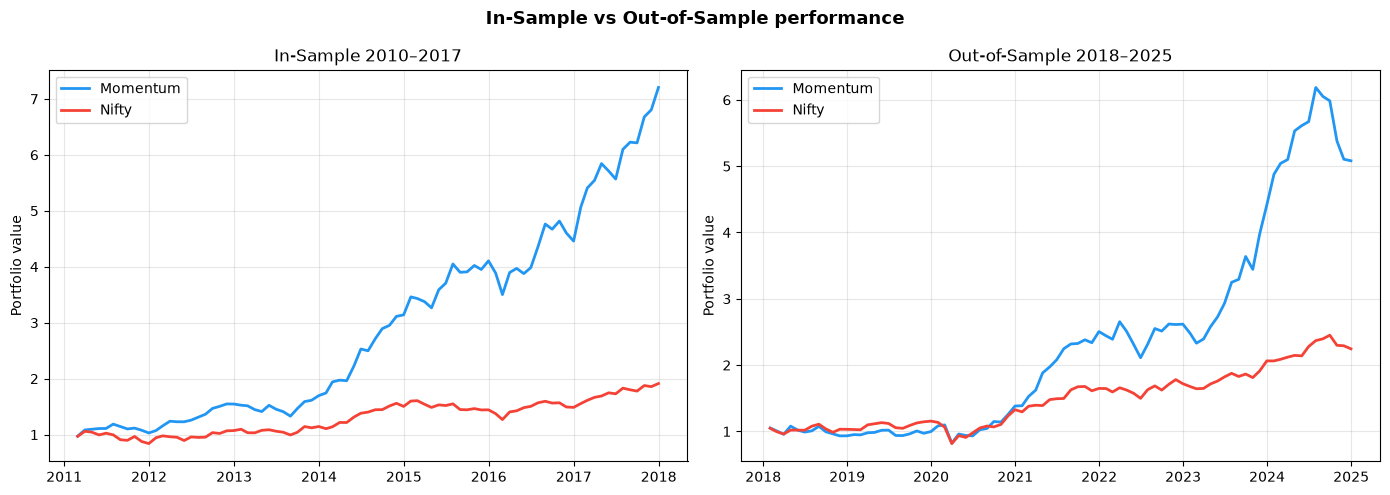

In [8]:
oos_date = pd.Timestamp(OOS_START)

lo_is  = long_only[long_only.index <  oos_date]
lo_oos = long_only[long_only.index >= oos_date]
bm_is  = bmk[bmk.index <  oos_date]
bm_oos = bmk[bmk.index >= oos_date]

split_table = pd.DataFrame({
    'Momentum IS (2010-17)' : metrics(lo_is),
    'Nifty IS (2010-17)'    : metrics(bm_is),
    'Momentum OOS (2018-25)': metrics(lo_oos),
    'Nifty OOS (2018-25)'   : metrics(bm_oos),
}).T
fmt2 = split_table.copy()
for c in ['CAGR','MaxDD','Win rate']:
    fmt2[c] = (fmt2[c]*100).round(1).astype(str)+'%'
fmt2['Sharpe'] = split_table['Sharpe'].round(2)
fmt2 = fmt2.drop(columns=['Avg turnover'], errors='ignore')
print(fmt2)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lo_r, bm_r, title in [
    (axes[0], lo_is,  bm_is,  'In-Sample 2010–2017'),
    (axes[1], lo_oos, bm_oos, 'Out-of-Sample 2018–2025'),
]:
    eq_lo = (1 + lo_r).cumprod()
    eq_bm = (1 + bm_r).cumprod()
    ax.plot(eq_lo.index, eq_lo, label='Momentum', color='#2196F3', linewidth=2)
    ax.plot(eq_bm.index, eq_bm, label='Nifty',    color='#F44336', linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Portfolio value')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('In-Sample vs Out-of-Sample performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('oos_validation.png', dpi=150)
plt.show()


## 8. Robustness — four lookback windows


                CAGR  Sharpe   MaxDD Win rate
3-1 momentum   20.8%    0.97  -34.0%    65.3%
6-1 momentum   24.3%    1.12  -30.7%    66.5%
9-1 momentum   25.4%    1.16  -23.9%    63.5%
12-1 momentum  29.5%    1.34  -25.1%    62.9%
Nifty          11.0%    0.72  -29.3%    56.3%


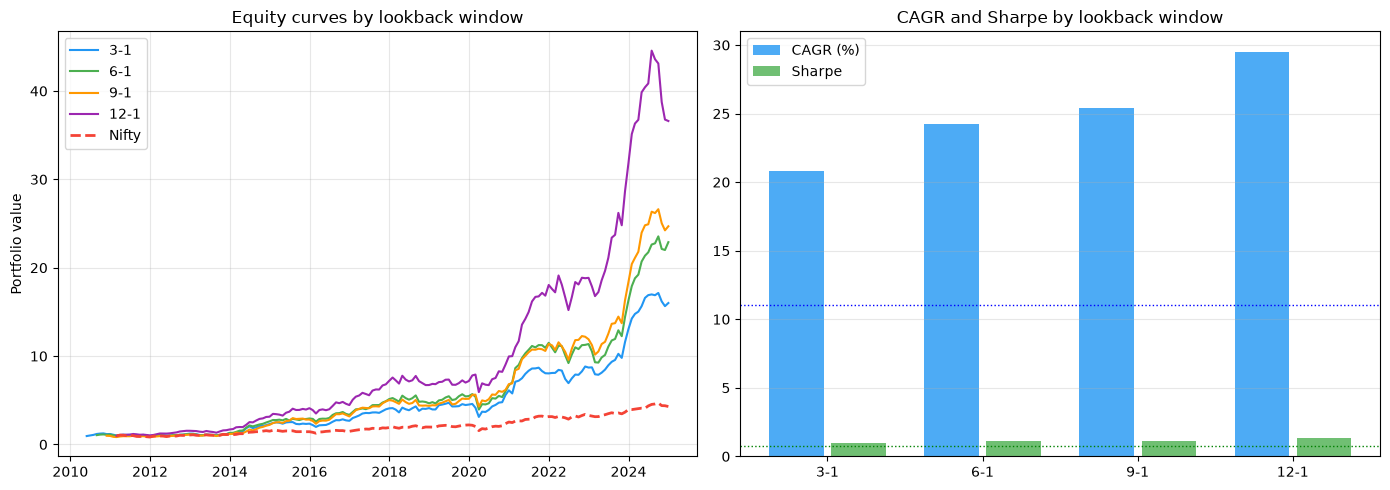

In [9]:
windows = [3, 6, 9, 12]
robust_res = {}
for w in windows:
    lo, _, _, _ = run_backtest(prices, w)
    robust_res[f'{w}-1 momentum'] = metrics(lo)
robust_res['Nifty'] = metrics(bmk)
rob = pd.DataFrame(robust_res).T
rob_fmt = rob.copy()
for c in ['CAGR','MaxDD','Win rate']:
    rob_fmt[c] = (rob_fmt[c]*100).round(1).astype(str)+'%'
rob_fmt['Sharpe'] = rob['Sharpe'].round(2)
print(rob_fmt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
for i, w in enumerate(windows):
    lo, _, _, _ = run_backtest(prices, w)
    eq = (1 + lo).cumprod()
    axes[0].plot(eq.index, eq, label=f'{w}-1', color=colors[i], linewidth=1.5)
eq_bmk = (1 + bmk).cumprod()
axes[0].plot(eq_bmk.index, eq_bmk, label='Nifty', color=colors[4], linewidth=2, linestyle='--')
axes[0].set_title('Equity curves by lookback window')
axes[0].set_ylabel('Portfolio value')
axes[0].legend()
axes[0].grid(alpha=0.3)
cagrs   = [robust_res[f'{w}-1 momentum']['CAGR']*100 for w in windows]
sharpes = [robust_res[f'{w}-1 momentum']['Sharpe'] for w in windows]
x = np.arange(len(windows))
axes[1].bar(x-0.2, cagrs,   0.35, label='CAGR (%)', color='#2196F3', alpha=0.8)
axes[1].bar(x+0.2, sharpes, 0.35, label='Sharpe',   color='#4CAF50', alpha=0.8)
axes[1].axhline(metrics(bmk)['CAGR']*100, color='blue',  linestyle=':', linewidth=1)
axes[1].axhline(metrics(bmk)['Sharpe'],   color='green', linestyle=':', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{w}-1' for w in windows])
axes[1].set_title('CAGR and Sharpe by lookback window')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('robustness_sweep.png', dpi=150)
plt.show()


## 9. Sector exposure analysis

One key interview question: *'Is this just a hidden sector bet?'*
For example, if momentum always loads heavily on IT during bull markets,
the returns might simply reflect the IT sector's performance, not momentum itself.

We plot the sector composition of the momentum portfolio over time to check this.


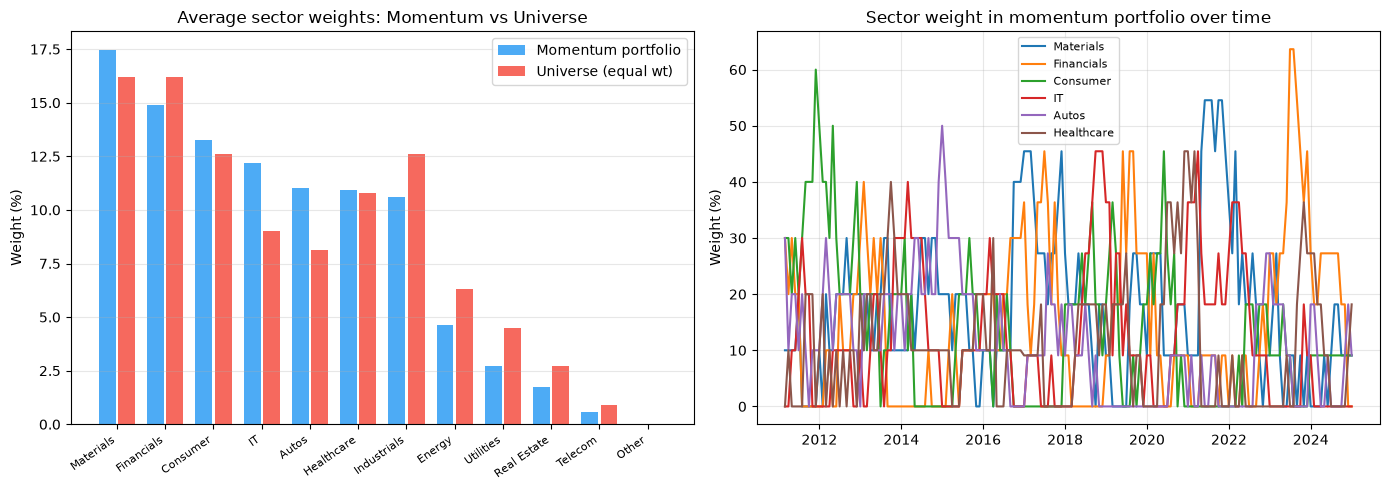

In [10]:
all_sectors = sorted(set(sector_map.values()))
dates_list  = long_only.index.tolist()
sector_weights = {s: [] for s in all_sectors}
sector_weights['Other'] = []

for h in holdings:
    counts = {s: 0 for s in all_sectors}
    counts['Other'] = 0
    for ticker in h:
        s = sector_map.get(ticker, 'Other')
        counts[s] = counts.get(s, 0) + 1
    total = len(h)
    for s in all_sectors:
        sector_weights[s].append(counts[s] / total * 100)
    sector_weights['Other'].append(counts['Other'] / total * 100)

sw_df = pd.DataFrame(sector_weights, index=dates_list)

# Average sector weights: momentum portfolio vs equal-weight universe
mom_avg = sw_df.mean().sort_values(ascending=False)
uni_avg = pd.Series({
    s: sum(1 for t in prices.columns if sector_map.get(t,'Other')==s)/len(prices.columns)*100
    for s in list(all_sectors)+['Other']
}).reindex(mom_avg.index).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(mom_avg))
axes[0].bar(x-0.2, mom_avg.values, 0.35, label='Momentum portfolio', color='#2196F3', alpha=0.8)
axes[0].bar(x+0.2, uni_avg.values, 0.35, label='Universe (equal wt)', color='#F44336', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(mom_avg.index, rotation=35, ha='right', fontsize=8)
axes[0].set_title('Average sector weights: Momentum vs Universe')
axes[0].set_ylabel('Weight (%)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

top_sectors = mom_avg.head(6).index.tolist()
for s in top_sectors:
    axes[1].plot(sw_df.index, sw_df[s], label=s, linewidth=1.5)
axes[1].set_title('Sector weight in momentum portfolio over time')
axes[1].set_ylabel('Weight (%)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sector_exposure.png', dpi=150)
plt.show()


## 10. Market beta and Jensen's alpha

*'Is the strategy just leveraged beta?'* — a common recruiter question.

We run a simple regression: **strategy return = alpha + beta × Nifty return**

- **Beta** close to 1.0 means the strategy moves with the market.
- **Beta** below 1.0 means lower market sensitivity — better risk-adjusted returns.
- **Alpha** is the return above what beta alone explains. Positive alpha is the goal.
- **Annualised alpha** tells us how much genuine skill (or survivorship bias) contributes.


Market Beta        : 0.897
Monthly Alpha      : 0.0148 (1.48%)
Annualised Alpha   : 19.22%
R-squared          : 0.486
P-value (beta)     : 0.0000

Interpretation:
  Beta 0.90 means for every 1% the Nifty moves, strategy moves 0.90%
  Annual alpha 19.2% — return not explained by market exposure
  R² 0.49 means 49% of strategy variance explained by market


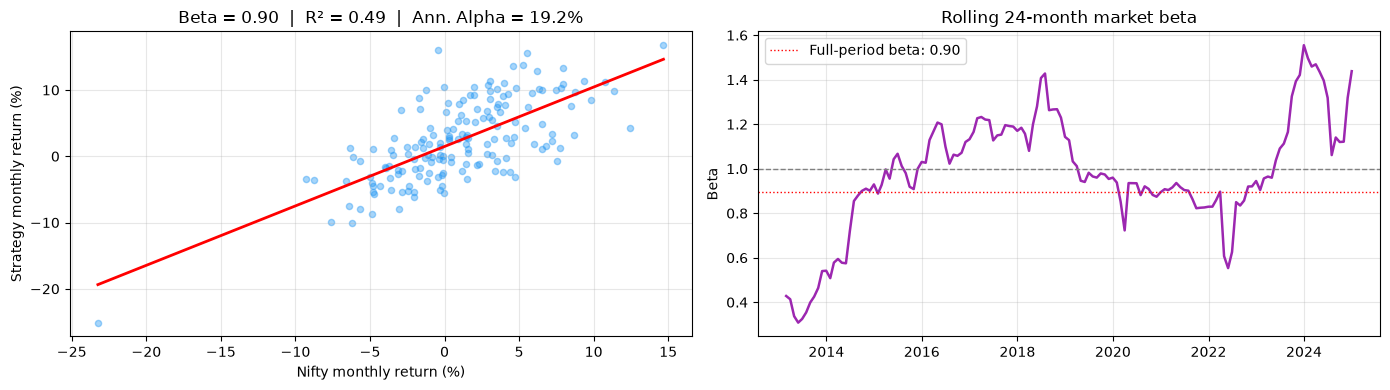

In [11]:
slope, intercept, r_val, p_val, se = stats.linregress(bmk, long_only)
ann_alpha = (1 + intercept)**12 - 1

print(f'Market Beta        : {slope:.3f}')
print(f'Monthly Alpha      : {intercept:.4f} ({intercept*100:.2f}%)')
print(f'Annualised Alpha   : {ann_alpha:.2%}')
print(f'R-squared          : {r_val**2:.3f}')
print(f'P-value (beta)     : {p_val:.4f}')
print()
print('Interpretation:')
print(f'  Beta {slope:.2f} means for every 1% the Nifty moves, strategy moves {slope:.2f}%')
print(f'  Annual alpha {ann_alpha:.1%} — return not explained by market exposure')
print(f'  R² {r_val**2:.2f} means {r_val**2*100:.0f}% of strategy variance explained by market')

# Rolling beta
roll_beta = pd.Series(dtype=float)
for end in range(24, len(long_only)):
    start = max(0, end-24)
    s, _, _, _, _ = stats.linregress(bmk.iloc[start:end], long_only.iloc[start:end])
    roll_beta[long_only.index[end]] = s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(bmk*100, long_only*100, alpha=0.4, s=20, color='#2196F3')
x_line = np.linspace(bmk.min()*100, bmk.max()*100, 100)
axes[0].plot(x_line, intercept*100 + slope*x_line, 'r-', linewidth=2)
axes[0].set_xlabel('Nifty monthly return (%)')
axes[0].set_ylabel('Strategy monthly return (%)')
axes[0].set_title(f'Beta = {slope:.2f}  |  R² = {r_val**2:.2f}  |  Ann. Alpha = {ann_alpha:.1%}')
axes[0].grid(alpha=0.3)
axes[1].plot(roll_beta.index, roll_beta, color='#9C27B0', linewidth=1.8)
axes[1].axhline(1, color='grey', linestyle='--', linewidth=1)
axes[1].axhline(slope, color='red', linestyle=':', linewidth=1, label=f'Full-period beta: {slope:.2f}')
axes[1].set_title('Rolling 24-month market beta')
axes[1].set_ylabel('Beta')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('factor_exposure.png', dpi=150)
plt.show()


## 11. Survivorship bias — quantifying the likely impact

We cannot remove survivorship bias without a paid point-in-time dataset.
But we can **quantify the estimated inflation** so we have a defensible number.

Academic research on Indian equities (Sehgal & Jain, 2011; NSE white papers) suggests
survivorship bias in Indian large-cap studies inflates returns by roughly **2–5% per year**.

Below we apply a range of haircuts to show what the strategy's true CAGR might be.


In [12]:
true_cagr_full, _ = (lambda r: ((1+r).cumprod().iloc[-1]**(12/len(r))-1, None))(long_only)

print('Survivorship bias sensitivity analysis')
print('='*55)
print(f"{'Assumed bias':<20} {'Adjusted CAGR':<18} {'Nifty CAGR':<12}")
print('-'*55)
for bias in [0.00, 0.01, 0.02, 0.03, 0.04, 0.05]:
    cagr_full = metrics(long_only)['CAGR']
    adj = cagr_full - bias
    nifty_cagr = metrics(bmk)['CAGR']
    still_beats = '✓ beats Nifty' if adj > nifty_cagr else '✗ no longer beats'
    print(f"  {bias:.0%} bias haircut     {adj:.1%}            {nifty_cagr:.1%}  {still_beats}")
print()
print('Even at a 5% survivorship haircut, momentum likely still beats the Nifty.')
print('This is the honest answer to give in interviews.')


Survivorship bias sensitivity analysis
Assumed bias         Adjusted CAGR      Nifty CAGR  
-------------------------------------------------------
  0% bias haircut     29.5%            11.0%  ✓ beats Nifty
  1% bias haircut     28.5%            11.0%  ✓ beats Nifty
  2% bias haircut     27.5%            11.0%  ✓ beats Nifty
  3% bias haircut     26.5%            11.0%  ✓ beats Nifty
  4% bias haircut     25.5%            11.0%  ✓ beats Nifty
  5% bias haircut     24.5%            11.0%  ✓ beats Nifty

Even at a 5% survivorship haircut, momentum likely still beats the Nifty.
This is the honest answer to give in interviews.


## 12. Equity curve vs Nifty


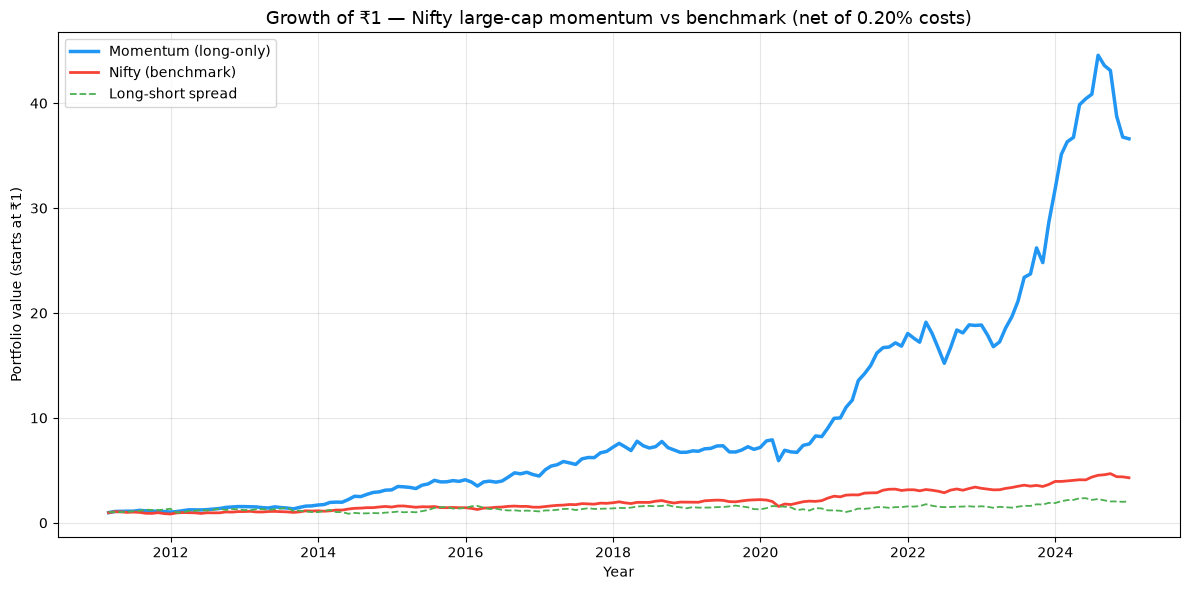

In [13]:
eq_long = (1 + long_only).cumprod()
eq_bmk  = (1 + bmk).cumprod()
eq_ls   = (1 + long_short).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(eq_long.index, eq_long, label='Momentum (long-only)', linewidth=2.5, color='#2196F3')
plt.plot(eq_bmk.index,  eq_bmk,  label='Nifty (benchmark)',   linewidth=2,   color='#F44336')
plt.plot(eq_ls.index,   eq_ls,   label='Long-short spread',   linewidth=1.3, color='#4CAF50', linestyle='--')
plt.title('Growth of ₹1 — Nifty large-cap momentum vs benchmark (net of 0.20% costs)', fontsize=13)
plt.ylabel('Portfolio value (starts at ₹1)')
plt.xlabel('Year')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150)
plt.show()


## 13. Drawdown chart


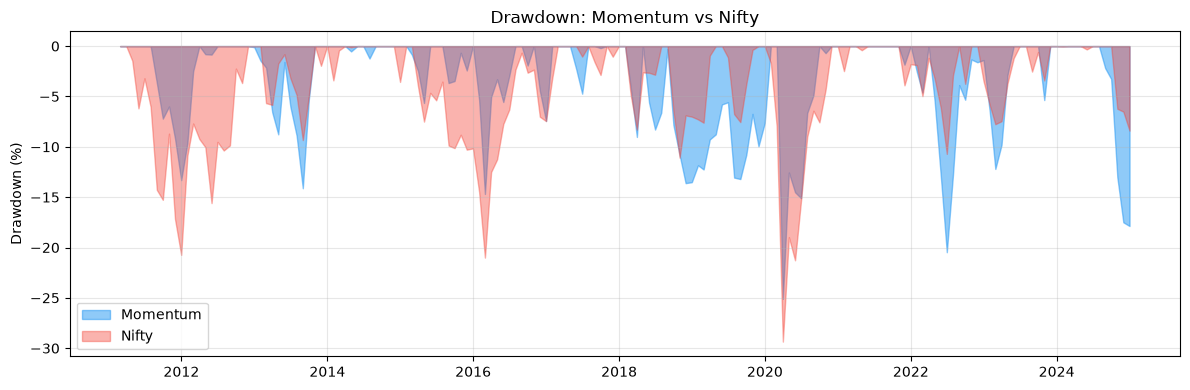

In [14]:
dd_long = eq_long / eq_long.cummax() - 1
dd_bmk  = eq_bmk  / eq_bmk.cummax()  - 1
plt.figure(figsize=(12, 4))
plt.fill_between(dd_long.index, dd_long*100, 0, alpha=0.5, color='#2196F3', label='Momentum')
plt.fill_between(dd_bmk.index,  dd_bmk*100,  0, alpha=0.4, color='#F44336', label='Nifty')
plt.title('Drawdown: Momentum vs Nifty')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown.png', dpi=150)
plt.show()


## 14. Rolling 12-month Sharpe ratio


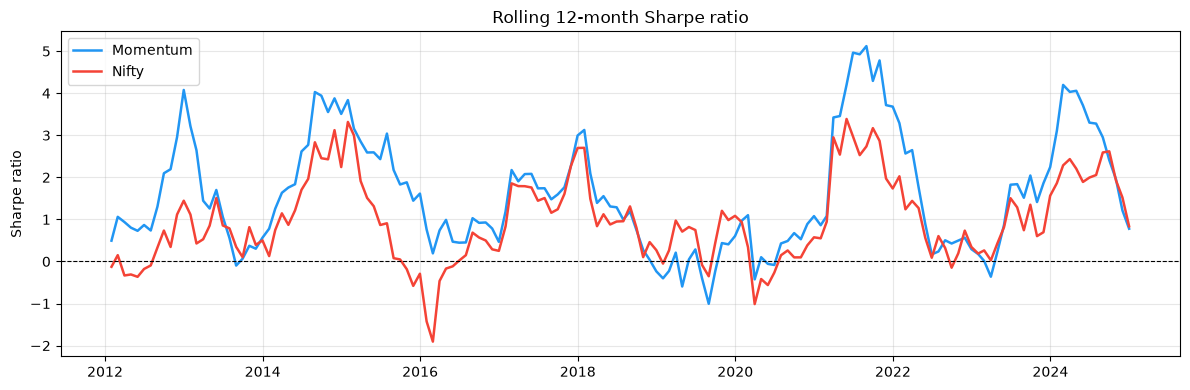

In [15]:
roll_s = (long_only.rolling(12).mean()/long_only.rolling(12).std())*np.sqrt(12)
roll_b = (bmk.rolling(12).mean()/bmk.rolling(12).std())*np.sqrt(12)
plt.figure(figsize=(12, 4))
plt.plot(roll_s.index, roll_s, label='Momentum', color='#2196F3', linewidth=1.8)
plt.plot(roll_b.index, roll_b, label='Nifty',    color='#F44336', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Rolling 12-month Sharpe ratio')
plt.ylabel('Sharpe ratio')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=150)
plt.show()


## 15. Monthly return heatmap


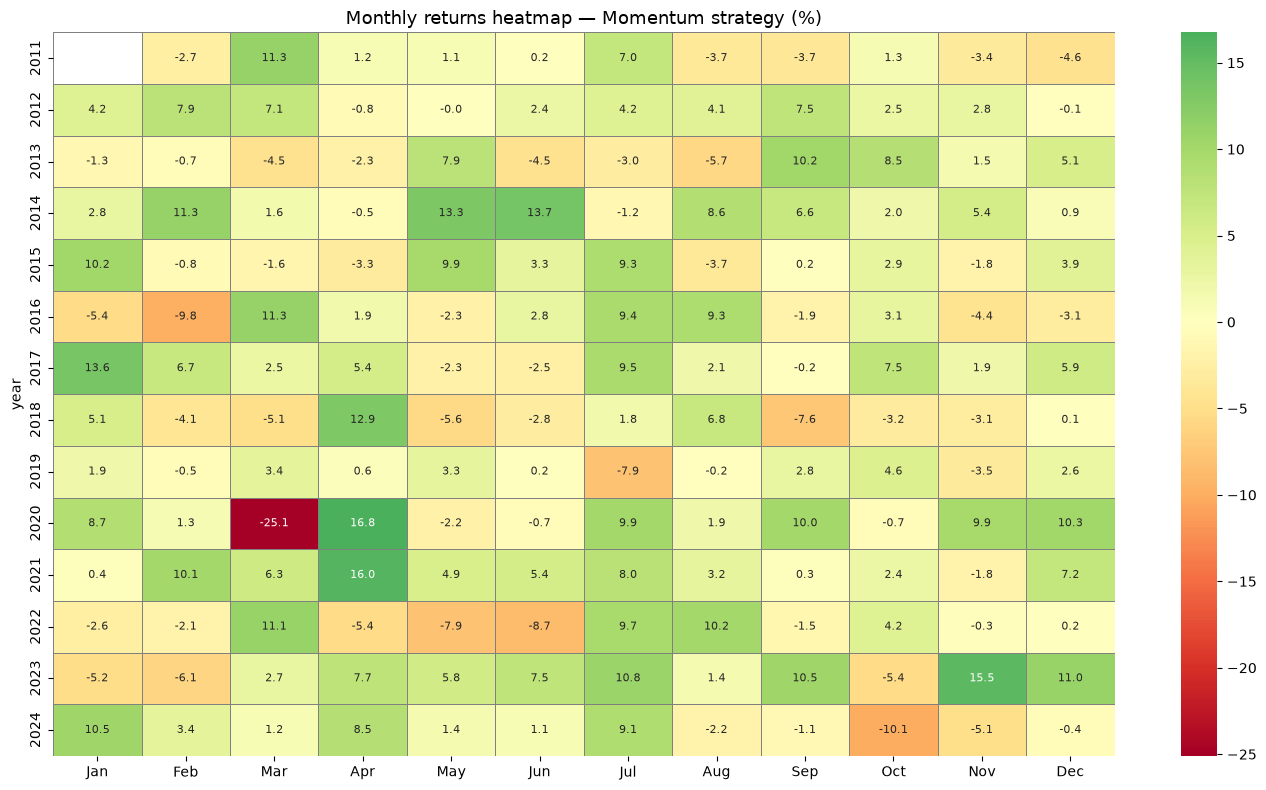

In [16]:
monthly_df = pd.DataFrame({'ret':long_only,'year':long_only.index.year,'month':long_only.index.month})
heat = monthly_df.pivot(index='year',columns='month',values='ret')*100
heat.columns=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(14,8))
sns.heatmap(heat,annot=True,fmt='.1f',cmap='RdYlGn',center=0,linewidths=0.5,linecolor='grey',annot_kws={'size':8})
plt.title('Monthly returns heatmap — Momentum strategy (%)',fontsize=13)
plt.tight_layout()
plt.savefig('monthly_heatmap.png',dpi=150)
plt.show()


## 16. Portfolio turnover


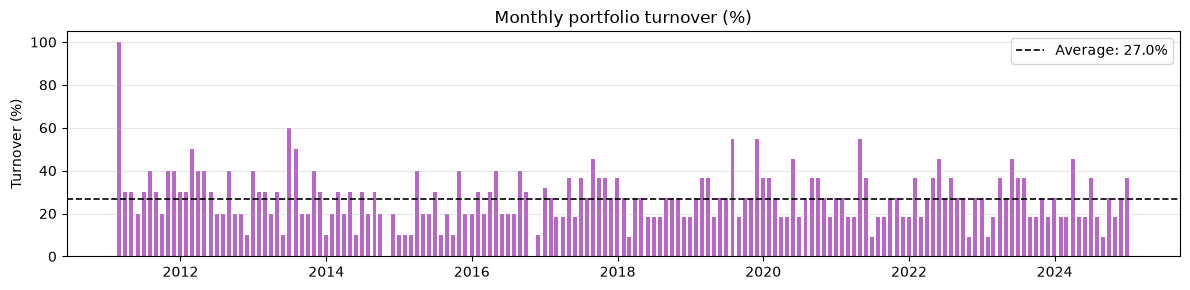

In [17]:
turn_series = pd.Series(turnovers, index=long_only.index)
plt.figure(figsize=(12,3))
plt.bar(turn_series.index, turn_series*100, width=20, color='#9C27B0', alpha=0.7)
plt.axhline(turn_series.mean()*100, color='black', linestyle='--', linewidth=1.2,
            label=f'Average: {turn_series.mean():.1%}')
plt.title('Monthly portfolio turnover (%)')
plt.ylabel('Turnover (%)')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('turnover.png', dpi=150)
plt.show()
